In [18]:
import pandas as pd
# Load the dataset
df = pd.read_csv("Amazon Sale Report.csv", encoding="latin1")

/tmp/ipykernel_3955/2971561717.py:3: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Amazon Sale Report.csv", encoding="latin1")


In [19]:
df.head()


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [20]:
df.shape


(128975, 24)

In [21]:
df.columns.tolist()

['index',
 'Order ID',
 'Date',
 'Status',
 'Fulfilment',
 'Sales Channel ',
 'ship-service-level',
 'Style',
 'SKU',
 'Category',
 'Size',
 'ASIN',
 'Courier Status',
 'Qty',
 'currency',
 'Amount',
 'ship-city',
 'ship-state',
 'ship-postal-code',
 'ship-country',
 'promotion-ids',
 'B2B',
 'fulfilled-by',
 'Unnamed: 22']

In [22]:
df.shape


(128975, 24)

In [23]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

In [24]:
# Step 3a: Drop the useless junk column
df = df.drop(columns=["Unnamed: 22"])


In [25]:
# Step 3b: Check how many missing values each column has
df.isnull().sum()


,0
index,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Style,0
SKU,0
Category,0


In [26]:
# Capture original row count BEFORE cleaning
original_rows = df.shape[0]
print("Original rows:", original_rows)

# Drop rows where 'Amount' is missing (critical for revenue analysis)
df = df.dropna(subset=["Amount"])

# Drop rows where 'Category' is missing (needed for product analysis)
df = df.dropna(subset=["Category"])

# Fill missing promotion IDs — blank means no promotion was applied
df["promotion-ids"] = df["promotion-ids"].fillna("No Promotion")

# Fix Date column — convert from text to proper datetime format
df["Date"] = pd.to_datetime(df["Date"], infer_datetime_format=True, errors="coerce")

# Clean version — no warning
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")


# Final check
print("Rows after cleaning :", df.shape[0])
print("Rows removed        :", original_rows - df.shape[0])
print("Columns remaining   :", df.shape[1])


Original rows: 128975
Rows after cleaning : 121180
Rows removed        : 7795
Columns remaining   : 23


/tmp/ipykernel_3955/464464143.py:15: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df["Date"] = pd.to_datetime(df["Date"], infer_datetime_format=True, errors="coerce")
/tmp/ipykernel_3955/464464143.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"], infer_datetime_format=True, errors="coerce")


In [27]:
# What is the total revenue, total orders, and average order value?
total_revenue = df["Amount"].sum()
total_orders = df["Order ID"].count()
avg_order_value = df["Amount"].mean()

print(f"Total Revenue     : ₹{total_revenue:,.2f}")
print(f"Total Orders      : {total_orders:,}")
print(f"Avg Order Value   : ₹{avg_order_value:,.2f}")


Total Revenue     : ₹78,592,678.30
Total Orders      : 121,180
Avg Order Value   : ₹648.56


In [28]:
# Which product categories generate the most revenue?
category_revenue = df.groupby("Category")["Amount"].sum().sort_values(ascending=False)
print(category_revenue)


Category
Set              39204124.03
kurta            21299546.70
Western Dress    11216072.69
Top               5347792.30
Ethnic Dress       791217.66
Blouse             458408.18
Bottom             150667.98
Saree              123933.76
Dupatta               915.00
Name: Amount, dtype: float64


In [29]:
# Which states are generating the most orders?
state_orders = df.groupby("ship-state")["Order ID"].count().sort_values(ascending=False).head(10)
print(state_orders)


ship-state
MAHARASHTRA       21073
KARNATAKA         16394
TAMIL NADU        10809
TELANGANA         10637
UTTAR PRADESH      9947
DELHI              6393
KERALA             6151
WEST BENGAL        5547
ANDHRA PRADESH     5055
HARYANA            4188
Name: Order ID, dtype: int64


In [30]:
# Which states are generating the most revenue?
state_revenue = df.groupby("ship-state")["Amount"].sum().sort_values(ascending=False).head(10)
print(state_revenue)


ship-state
MAHARASHTRA       13335534.14
KARNATAKA         10481114.37
TELANGANA          6916615.65
UTTAR PRADESH      6816642.08
TAMIL NADU         6515650.11
DELHI              4235215.97
KERALA             3830227.58
WEST BENGAL        3507880.44
ANDHRA PRADESH     3219831.72
HARYANA            2882092.99
Name: Amount, dtype: float64


In [31]:
# Extract month from the Date column
df["Month"] = df["Date"].dt.month

# Total revenue per month
monthly_revenue = df.groupby("Month")["Amount"].sum().sort_index()
print(monthly_revenue)


Month
3      101683.85
4    28838708.32
5    26226476.75
6    23425809.38
Name: Amount, dtype: float64


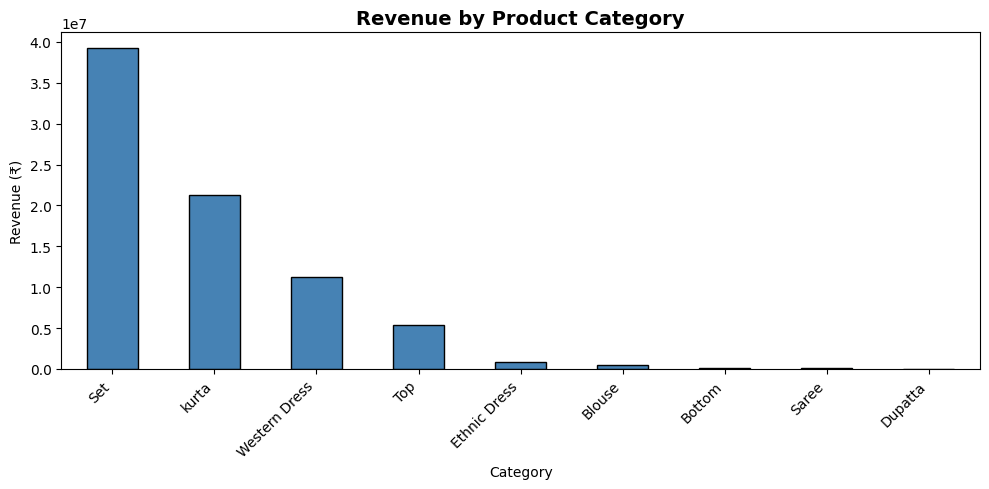

Chart 1 saved!


In [32]:
import matplotlib.pyplot as plt

# ── Chart 1: Revenue by Category (Bar Chart) ──────────────────
plt.figure(figsize=(10, 5))
category_revenue.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Revenue by Product Category", fontsize=14, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("chart1_category_revenue.png", dpi=150)
plt.show()
print("Chart 1 saved!")


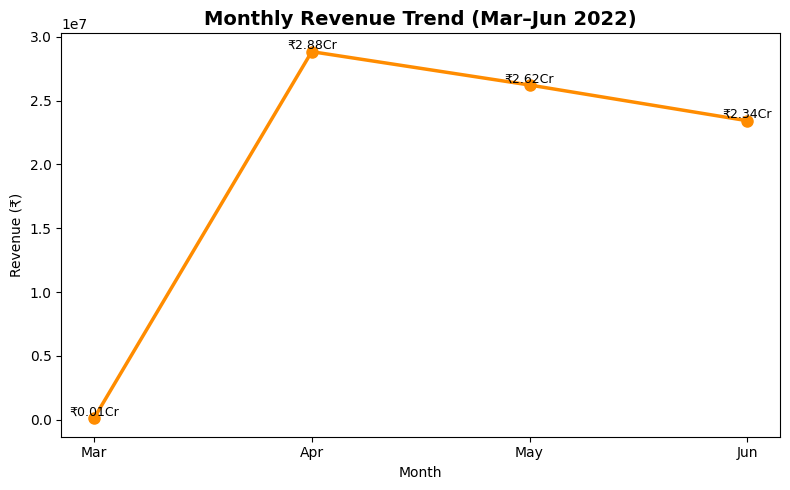

Chart 2 saved!


In [33]:
# ── Chart 2: Monthly Revenue Trend (Line Chart) ───────────────
month_labels = {3: "Mar", 4: "Apr", 5: "May", 6: "Jun"}

plt.figure(figsize=(8, 5))
plt.plot(monthly_revenue.index, monthly_revenue.values,
         marker="o", color="darkorange", linewidth=2.5, markersize=8)

# Add value labels on each data point
for x, y in zip(monthly_revenue.index, monthly_revenue.values):
    plt.text(x, y + 200000, f"₹{y/1e7:.2f}Cr", ha="center", fontsize=9)

plt.title("Monthly Revenue Trend (Mar–Jun 2022)", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Revenue (₹)")
plt.xticks(monthly_revenue.index, [month_labels[m] for m in monthly_revenue.index])
plt.tight_layout()
plt.savefig("chart2_monthly_trend.png", dpi=150)
plt.show()
print("Chart 2 saved!")


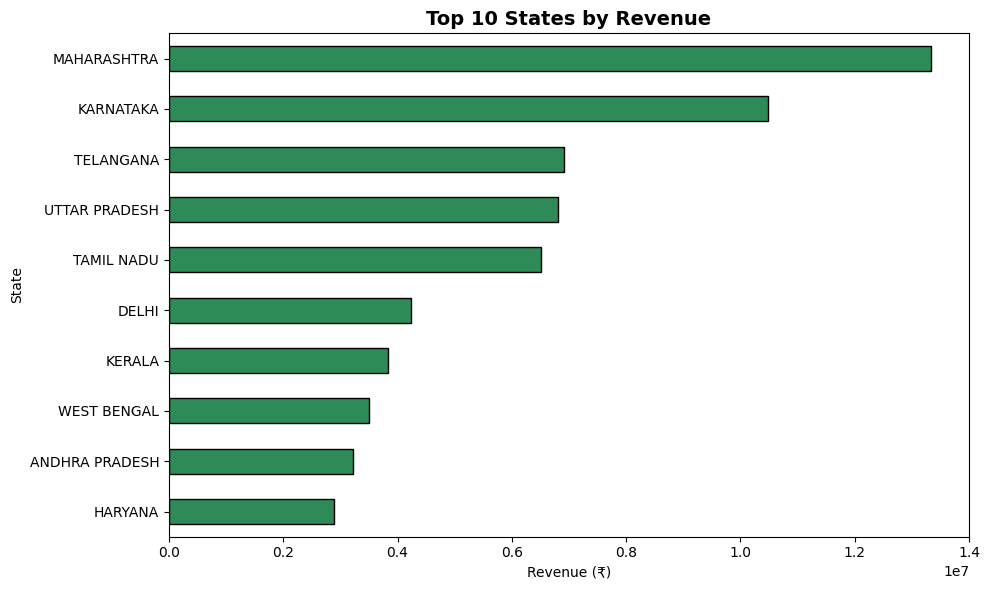

Chart 3 saved!


In [34]:
# ── Chart 3: Top 10 States by Revenue ─────────────────────────
plt.figure(figsize=(10, 6))
state_revenue.sort_values().plot(kind="barh", color="seagreen", edgecolor="black")
plt.title("Top 10 States by Revenue", fontsize=14, fontweight="bold")
plt.xlabel("Revenue (₹)")
plt.ylabel("State")
plt.tight_layout()
plt.savefig("chart3_state_revenue.png", dpi=150)
plt.show()
print("Chart 3 saved!")


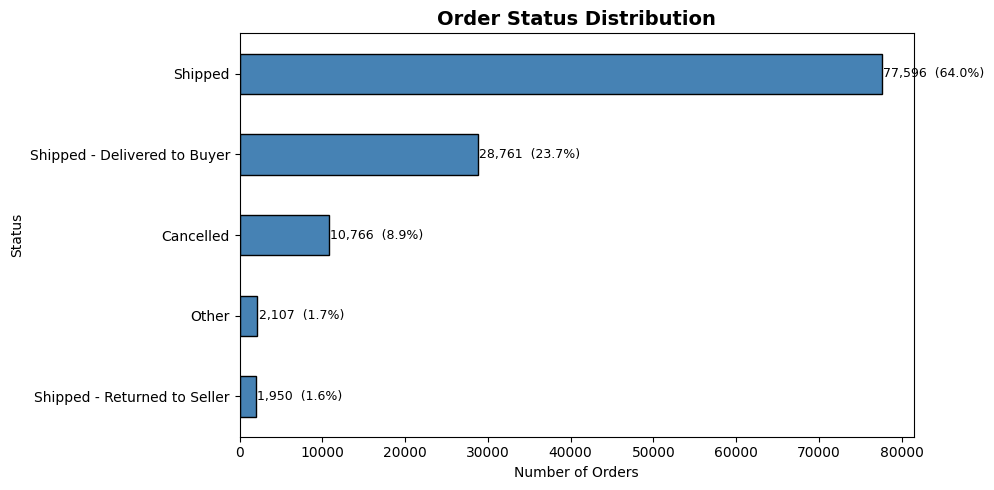

Chart 4 saved!


In [35]:
# ── Chart 4 (Final): Order Status with Count + Percentage ─────

status_counts = df["Status"].value_counts()
threshold = len(df) * 0.01
major = status_counts[status_counts >= threshold]
other = status_counts[status_counts < threshold].sum()
status_clean = pd.concat([major, pd.Series({"Other": other})])

total = status_clean.sum()

plt.figure(figsize=(10, 5))
status_clean.sort_values().plot(kind="barh", color="steelblue", edgecolor="black")
plt.title("Order Status Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Number of Orders")
plt.ylabel("Status")

# Show both count AND percentage on each bar
for i, (status, v) in enumerate(status_clean.sort_values().items()):
    pct = (v / total) * 100
    plt.text(v + 200, i, f"{v:,.0f}  ({pct:.1f}%)", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("chart4_order_status.png", dpi=150)
plt.show()
print("Chart 4 saved!")


In [36]:
# Export cleaned data for Excel dashboard
df.to_csv("amazon_cleaned.csv", index=False)
print("File saved! Download it from the Colab file panel on the left.")


File saved! Download it from the Colab file panel on the left.


In [37]:
cancelled_revenue = df[df["Status"] == "Cancelled"]["Amount"].sum()
print(f"Potential lost revenue from cancellations: ₹{cancelled_revenue:,.2f}")


Potential lost revenue from cancellations: ₹6,919,284.30
